# Expectation of a Discrete Random Variable

Let $X$ be a discrete random variable that can take $N_x$ possible values $x_1, x_2, \ldots, x_{N_x}$.

The **expectation** (also called the **mean**) of $X$ is:

$$\boxed{E[X] = \sum_{i=1}^{N_x} P(X = x_i)\; x_i = \sum_X P(X)\; X}$$

- $E[X]$ is the probability-weighted average of all values $X$ can take
- $E[X]$ is referred to as the **mean** $\mu$ of the random variable: $\mu = E[X]$
- $E[X]$ is the **first-order statistical moment** of $X$

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.alpha':       0.35,
    'font.size':        11,
})

## Illustration — Weighted (Non-uniform) Probabilities

From the slide:

| | $x_1$ | $x_2$ | $x_3$ |
|---|---|---|---|
| $X$ | 5 | 10 | 15 |
| $P(X)$ | 0.4 | 0.25 | 0.35 |

$$\mu = E[X] = (0.4 \times 5) + (0.25 \times 10) + (0.35 \times 15) = 2 + 2.5 + 5.25 = 9.75$$

Weighted expectation  E[X] = Σ P(X=xᵢ)·xᵢ
────────────────────────────────────────
  P(X= 5) ×  5  =  0.40 ×  5  =  2.0000
  P(X=10) × 10  =  0.25 × 10  =  2.5000
  P(X=15) × 15  =  0.35 × 15  =  5.2500
────────────────────────────────────────
  E[X] = 9.7500


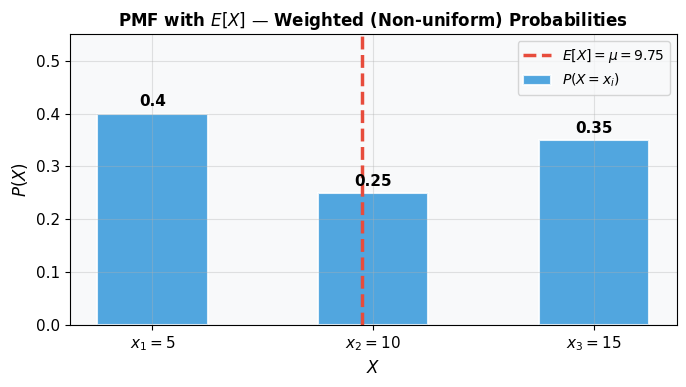

In [8]:
# --- Slide illustration: weighted case ---
values = np.array([5, 10, 15])
probs  = np.array([0.4, 0.25, 0.35])

E_X = np.sum(probs * values)

print("Weighted expectation  E[X] = Σ P(X=xᵢ)·xᵢ")
print("─" * 40)
for xi, pi in zip(values, probs):
    print(f"  P(X={xi:2d}) × {xi:2d}  =  {pi:.2f} × {xi:2d}  =  {pi*xi:.4f}")
print("─" * 40)
print(f"  E[X] = {E_X:.4f}")

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(values, probs, width=2.5, color='#3498db', edgecolor='white', linewidth=1.5,
              alpha=0.85, label='$P(X = x_i)$')
ax.axvline(E_X, color='#e74c3c', lw=2.5, ls='--', label=f'$E[X] = \\mu = {E_X}$')

# annotate each bar
for xi, pi in zip(values, probs):
    ax.text(xi, pi + 0.008, f'{pi}', ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_xticks(values)
ax.set_xticklabels([f'$x_{i+1}={v}$' for i, v in enumerate(values)])
ax.set_xlabel('$X$', fontsize=12)
ax.set_ylabel('$P(X)$', fontsize=12)
ax.set_title('PMF with $E[X]$ — Weighted (Non-uniform) Probabilities', fontsize=12, fontweight='bold')
ax.set_ylim(0, 0.55)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Arithmetic Mean as a Special Case

When all values are **equally likely** — i.e. $P(X = x_i) = \dfrac{1}{N_x}$ for all $i$ — the expectation reduces to the familiar **arithmetic average**:

$$\mu = \frac{1}{N_x} \sum_{i=1}^{N_x} x_i$$

From the slide (same values, uniform probabilities):

| | $x_1$ | $x_2$ | $x_3$ |
|---|---|---|---|
| $X$ | 5 | 10 | 15 |
| $P(X)$ | $\tfrac{1}{3}$ | $\tfrac{1}{3}$ | $\tfrac{1}{3}$ |

$$\mu = \frac{1}{3}(5 + 10 + 15) = \frac{30}{3} = 10$$

> The weighted case ($\mu = 9.75$) and the uniform case ($\mu = 10$) differ because the highest value $x_3 = 15$ gets less weight (0.35 vs 0.4 for $x_1 = 5$ which pulls the mean down).

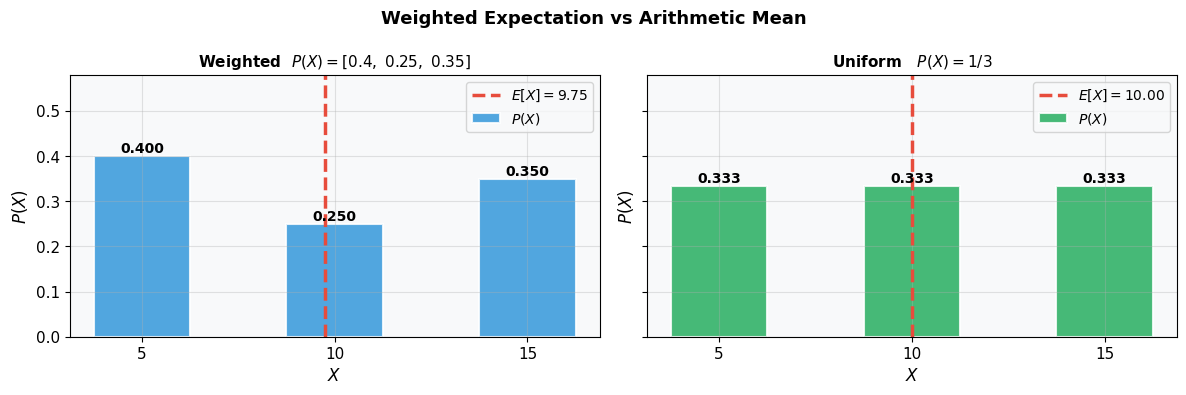

Weighted   E[X] = 9.7500
Uniform    E[X] = 10.0000  (= arithmetic mean)


In [9]:
# --- Weighted vs Uniform: side-by-side comparison ---
values_u = np.array([5, 10, 15])
probs_u  = np.ones(3) / 3          # uniform P(X) = 1/3
E_X_u    = np.sum(probs_u * values_u)

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, probs_p, E_p, title, color in zip(
    axes,
    [probs, probs_u],
    [E_X,   E_X_u],
    ['Weighted  $P(X) = [0.4,\\ 0.25,\\ 0.35]$',
     'Uniform   $P(X) = 1/3$'],
    ['#3498db', '#27ae60']
):
    ax.bar(values, probs_p, width=2.5, color=color, edgecolor='white',
           linewidth=1.5, alpha=0.85, label='$P(X)$')
    ax.axvline(E_p, color='#e74c3c', lw=2.5, ls='--',
               label=f'$E[X] = {E_p:.2f}$')
    for xi, pi in zip(values, probs_p):
        ax.text(xi, pi + 0.008, f'{pi:.3f}', ha='center', fontsize=10, fontweight='bold')
    ax.set_xticks(values)
    ax.set_xlabel('$X$', fontsize=12)
    ax.set_ylabel('$P(X)$', fontsize=12)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_ylim(0, 0.58)
    ax.legend(fontsize=10)

plt.suptitle('Weighted Expectation vs Arithmetic Mean', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Weighted   E[X] = {E_X:.4f}")
print(f"Uniform    E[X] = {E_X_u:.4f}  (= arithmetic mean)")

## E[X] as the Centre of Mass

Geometrically, $E[X]$ is the **balance point** of the PMF — if each bar's probability were a weight, the distribution would balance exactly at $\mu$.

The contribution of each value $x_i$ to the mean is $P(X=x_i) \cdot x_i$ — values with higher probability pull the mean towards them.

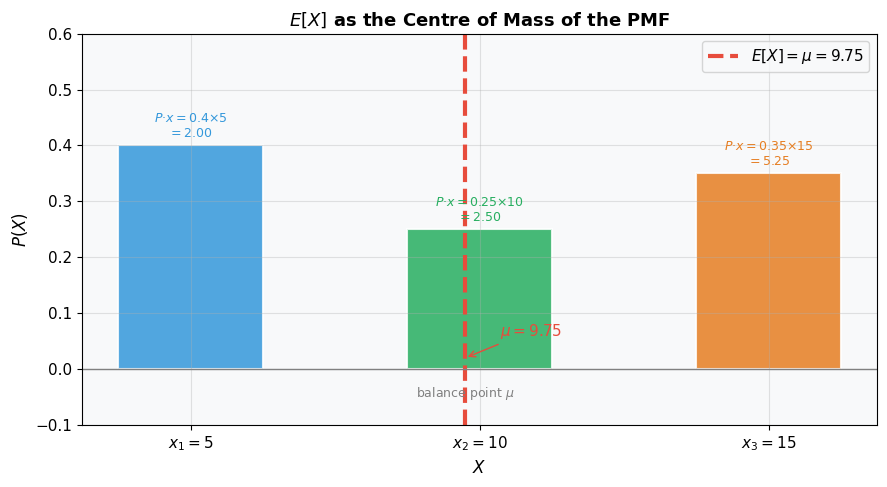

Contributions  P(X=xᵢ)·xᵢ:
  0.40 × 5 = 2.0000
  0.25 × 10 = 2.5000
  0.35 × 15 = 5.2500
  Sum = 9.7500  →  E[X] = 9.75


In [10]:
# --- Centre of mass visualisation ---
fig, ax = plt.subplots(figsize=(9, 5))

bar_colors = ['#3498db', '#27ae60', '#e67e22']
contributions = probs * values     # P(xᵢ)·xᵢ

bars = ax.bar(values, probs, width=2.5, color=bar_colors, edgecolor='white',
              linewidth=1.5, alpha=0.85)

# annotate contribution
for xi, pi, ci, col in zip(values, probs, contributions, bar_colors):
    ax.text(xi, pi + 0.01, f'$P·x = {pi}×{xi}$\n$= {ci:.2f}$',
            ha='center', va='bottom', fontsize=9, color=col, fontweight='bold')

# balance point
ax.axvline(E_X, color='#e74c3c', lw=3, ls='--', label=f'$E[X] = \\mu = {E_X}$')
ax.annotate(f'$\\mu = {E_X}$', xy=(E_X, 0.02), xytext=(E_X + 0.6, 0.06),
            fontsize=11, color='#e74c3c', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#e74c3c'))

# draw a "balance beam" at y=0
ax.axhline(0, color='gray', lw=1)
ax.annotate('', xy=(values[-1]+2, -0.03), xytext=(values[0]-2, -0.03),
            arrowprops=dict(arrowstyle='<->', color='gray'))
ax.text(E_X, -0.05, 'balance point $\\mu$', ha='center', fontsize=9, color='gray')

ax.set_xticks(values)
ax.set_xticklabels([f'$x_{i+1}={v}$' for i, v in enumerate(values)], fontsize=11)
ax.set_xlabel('$X$', fontsize=12)
ax.set_ylabel('$P(X)$', fontsize=12)
ax.set_title('$E[X]$ as the Centre of Mass of the PMF', fontsize=13, fontweight='bold')
ax.set_ylim(-0.1, 0.6)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("Contributions  P(X=xᵢ)·xᵢ:")
for xi, pi, ci in zip(values, probs, contributions):
    print(f"  {pi:.2f} × {xi} = {ci:.4f}")
print(f"  Sum = {contributions.sum():.4f}  →  E[X] = {E_X}")

## E[X] for Common Discrete Distributions

| Distribution | Parameters | $E[X]$ |
|---|---|---|
| **Bernoulli** | $p$ | $p$ |
| **Binomial** | $n, p$ | $np$ |
| **Geometric** | $p$ | $1/p$ |
| **Poisson** | $\lambda$ | $\lambda$ |

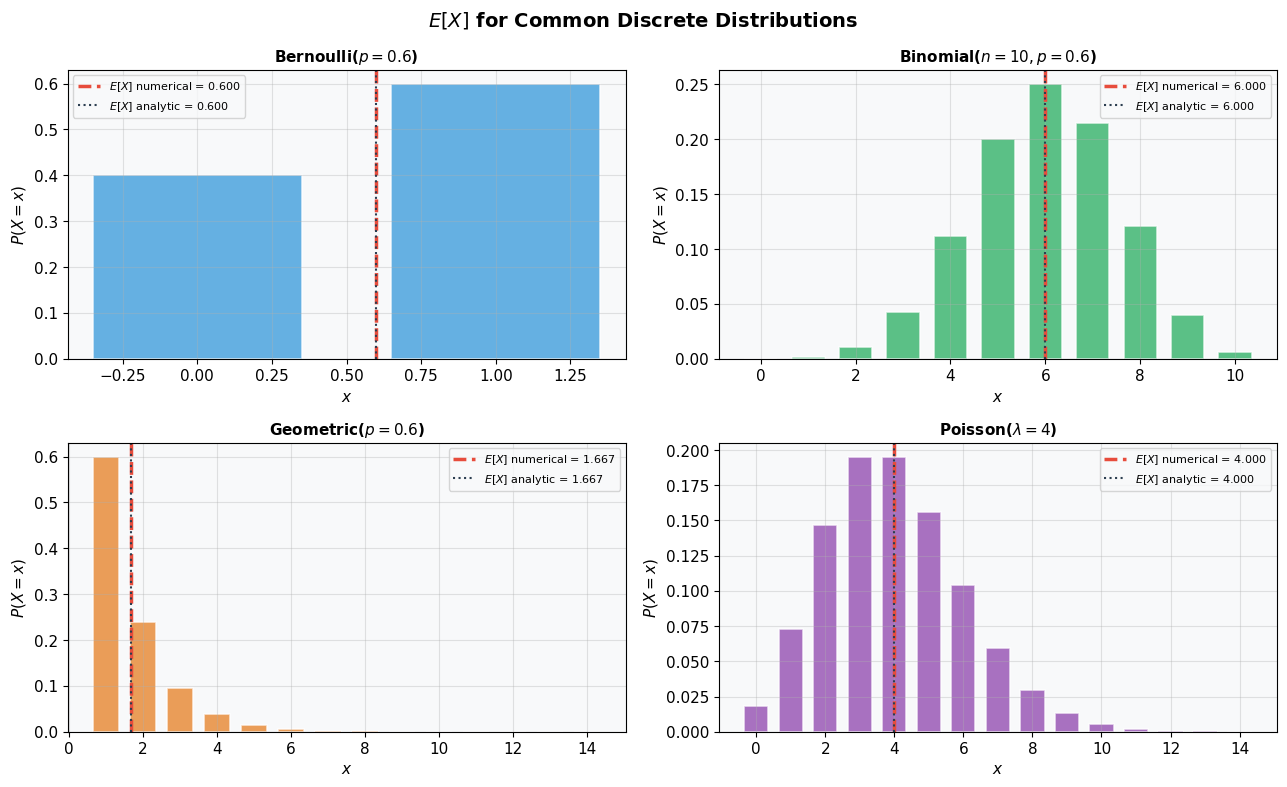

Distribution                   E[X] numerical   E[X] analytic
──────────────────────────────────────────────────────────────
Bernoulli(p=0.6)                       0.6000          0.6000
Binomial(n=10,p=0.6)                   6.0000          6.0000
Geometric(p=0.6)                       1.6666          1.6667
Poisson(λ=4)                           3.9997          4.0000


In [11]:
from scipy.stats import bernoulli, binom, geom, poisson

# Parameters
p, n, lam = 0.6, 10, 4

distributions = {
    'Bernoulli($p=0.6$)':   (bernoulli(p),   np.arange(0, 2),    '#3498db', p),
    'Binomial($n=10,p=0.6$)':(binom(n, p),   np.arange(0, n+1),  '#27ae60', n*p),
    'Geometric($p=0.6$)':   (geom(p),        np.arange(1, 15),   '#e67e22', 1/p),
    'Poisson($\\lambda=4$)': (poisson(lam),  np.arange(0, 15),   '#8e44ad', lam),
}

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('$E[X]$ for Common Discrete Distributions', fontsize=14, fontweight='bold')

for ax, (title, (dist, xs, col, ex_analytic)) in zip(axes.flat, distributions.items()):
    pmf = dist.pmf(xs)
    E_numerical = np.sum(pmf * xs)

    ax.bar(xs, pmf, color=col, alpha=0.75, edgecolor='white', linewidth=1.2, width=0.7)
    ax.axvline(E_numerical, color='#e74c3c', lw=2.5, ls='--',
               label=f'$E[X]$ numerical = {E_numerical:.3f}')
    ax.axvline(ex_analytic, color='#2c3e50', lw=1.5, ls=':',
               label=f'$E[X]$ analytic = {ex_analytic:.3f}')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('$x$'); ax.set_ylabel('$P(X=x)$')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"{'Distribution':<28} {'E[X] numerical':>16} {'E[X] analytic':>15}")
print("─" * 62)
for title, (dist, xs, col, ex_analytic) in distributions.items():
    pmf = dist.pmf(xs)
    E_num = np.sum(pmf * xs)
    clean = title.replace('$', '').replace('\\lambda=4', 'λ=4')
    print(f"{clean:<28} {E_num:>16.4f} {ex_analytic:>15.4f}")

## Empirical Verification — Law of Large Numbers

As the number of samples $N \to \infty$, the **sample mean** converges to $E[X]$:

$$\bar{X}_N = \frac{1}{N}\sum_{i=1}^{N} x_i \;\xrightarrow{N\to\infty}\; E[X]$$

This is the **Law of Large Numbers** — the theoretical justification for using $E[X]$ to describe a distribution.

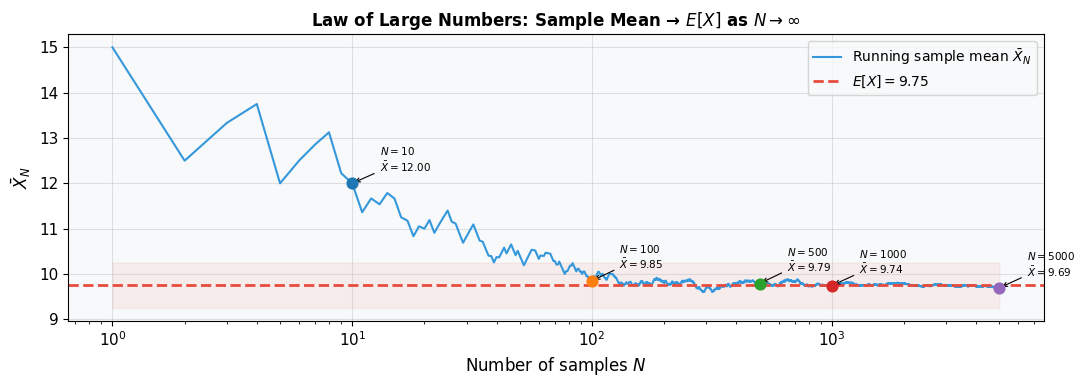

E[X] (theoretical)     = 9.7500
Sample mean (N=100)    = 9.8500
Sample mean (N=1000)   = 9.7450
Sample mean (N=5000)   = 9.6940


In [12]:
# --- Empirical sample mean converging to E[X] ---
rng = np.random.default_rng(42)

# Use the weighted distribution from the slide (X ∈ {5,10,15}, P = [0.4, 0.25, 0.35])
N_max = 5000
samples = rng.choice(values, size=N_max, p=probs)
running_mean = np.cumsum(samples) / np.arange(1, N_max + 1)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(np.arange(1, N_max + 1), running_mean, color='#3498db', lw=1.5,
        label='Running sample mean $\\bar{X}_N$')
ax.axhline(E_X, color='#e74c3c', lw=2, ls='--', label=f'$E[X] = {E_X}$')
ax.fill_between(np.arange(1, N_max + 1), E_X - 0.5, E_X + 0.5,
                color='#e74c3c', alpha=0.07)

# mark milestones
for n_milestone in [10, 100, 500, 1000, 5000]:
    val = running_mean[n_milestone - 1]
    ax.scatter([n_milestone], [val], s=60, zorder=5)
    ax.annotate(f'$N={n_milestone}$\n$\\bar{{X}}={val:.2f}$',
                xy=(n_milestone, val), xytext=(n_milestone * 1.3, val + 0.25 * (-1)**(n_milestone % 2)),
                fontsize=7.5, ha='left',
                arrowprops=dict(arrowstyle='->', lw=0.8))

ax.set_xlabel('Number of samples $N$', fontsize=12)
ax.set_ylabel('$\\bar{X}_N$', fontsize=12)
ax.set_title('Law of Large Numbers: Sample Mean → $E[X]$ as $N \\to \\infty$',
             fontsize=12, fontweight='bold')
ax.set_xscale('log')
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f"E[X] (theoretical)     = {E_X:.4f}")
print(f"Sample mean (N=100)    = {running_mean[99]:.4f}")
print(f"Sample mean (N=1000)   = {running_mean[999]:.4f}")
print(f"Sample mean (N=5000)   = {running_mean[4999]:.4f}")

## Summary

| Concept | Formula |
|---|---|
| **Expectation (general)** | $E[X] = \sum_i P(X=x_i)\cdot x_i$ |
| **Arithmetic mean (uniform)** | $\mu = \dfrac{1}{N_x}\sum_i x_i$ |
| **Mean = First-order moment** | $\mu = E[X]$ |
| **Law of Large Numbers** | $\bar{X}_N \to E[X]$ as $N \to \infty$ |

> $E[X]$ is the **balance point** of the PMF. Higher-probability values pull the mean toward them — the arithmetic mean is just the special case where every value has equal pull.